# Keras Hometask

#### Using all cpu threads 

In [1]:
import os
import multiprocessing

num_threads = multiprocessing.cpu_count()

os.environ["OMP_NUM_THREADS"] = str(num_threads)
os.environ["TF_NUM_INTRAOP_THREADS"] = str(num_threads)
os.environ["TF_NUM_INTEROP_THREADS"] = str(num_threads)

import tensorflow as tf

tf.config.threading.set_intra_op_parallelism_threads(num_threads)
tf.config.threading.set_inter_op_parallelism_threads(num_threads)
tf.config.set_soft_device_placement(True)


#### Load h5 dataset

In [2]:
import h5py
import numpy as np


def load_dataset():
    fn = 'data/train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    Y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn = 'data/test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    Y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes
train_data, train_labels, test_data, test_labels, classes = load_dataset()


print ('train_data.shape=', train_data.shape)
print ('train_labels.shape=',  train_labels.shape)
print ('test_data.shape=', test_data.shape)
print ('test_labels.shape=', test_labels.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


#### Preprocessing

In [3]:
from keras.utils import to_categorical

# Scaling samples
X_train = train_data / 255.0
X_test = test_data / 255.0

# Encoding
y_train_one_hot = to_categorical(train_labels[0], 6)
y_test_one_hot = to_categorical(test_labels[0], 6)


#### Model_1 simple CNN model

In [4]:
from keras.models import Sequential
from keras.layers import(
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten
)

model_1 = Sequential([
    Conv2D(
        filters=32,
        kernel_size=3,
        padding='same',
        activation='relu',
        input_shape=(64, 64, 3)
    ),
    MaxPooling2D(2),

    Conv2D(
        filters=64,
        kernel_size=3,
        padding='same',
        activation='relu'
    ),
    MaxPooling2D(2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])

/Users/deructu/amazinum/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Training model_1

In [5]:
model_1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_1 = model_1.fit(
    X_train,
    y_train_one_hot,
    batch_size=8,
    epochs=20,
    verbose=1,
    validation_data=(X_test, y_test_one_hot)
)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2120 - loss: 1.8223 - val_accuracy: 0.2833 - val_loss: 1.7388
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5352 - loss: 1.2212 - val_accuracy: 0.6833 - val_loss: 0.8752
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8056 - loss: 0.5935 - val_accuracy: 0.8083 - val_loss: 0.5083
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9083 - loss: 0.2958 - val_accuracy: 0.8583 - val_loss: 0.3586
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9343 - loss: 0.1895 - val_accuracy: 0.9000 - val_loss: 0.3488
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9778 - loss: 0.0820 - val_accuracy: 0.9167 - val_loss: 0.2905
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9889 - loss: 0.0470 - val_accuracy: 0.9000 - val_loss: 0.2605
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9981 - loss: 0.0240 - val_accuracy: 0

#### Plot curves for model_1

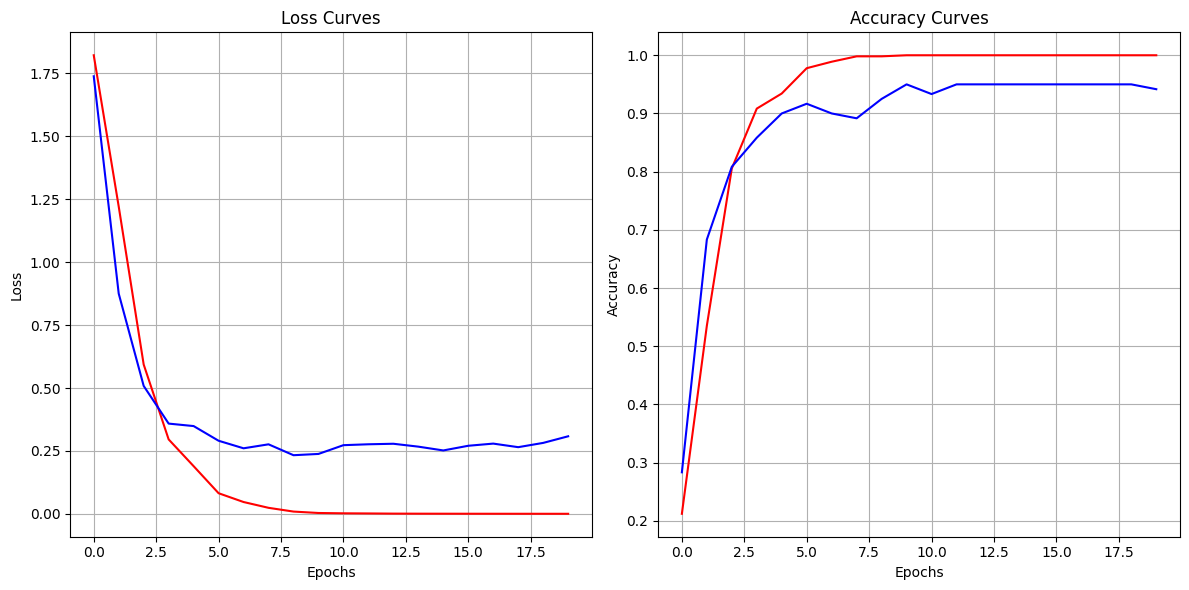

In [6]:
import matplotlib.pyplot as plt
def plot_curves(model_history):
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    
    axs[0].plot(model_history.history['loss'], color='r', label='Training loss')
    axs[0].plot(model_history.history['val_loss'], color='b', label='Validation loss')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Loss Curves')
    axs[0].grid(True)

    axs[1].plot(model_history.history['accuracy'], color='r', label='Training accuracy')
    axs[1].plot(model_history.history['val_accuracy'], color='b', label='Validation accuracy')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Accuracy')
    axs[1].set_title('Accuracy Curves')
    axs[1].grid(True)

    fig.tight_layout()


plot_curves(history_1)


#### Evaluating model_1

In [7]:
def evaluate_model(model):
    [test_loss, test_acc] = model.evaluate(X_test, y_test_one_hot)
    print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

evaluate_model(model_1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9417 - loss: 0.3082 
Evaluation result on Test Data : Loss = 0.30820977687835693, accuracy = 0.9416666626930237


#### Model_2 with new conv layer and Dropout (regularization)

In [8]:
model_2 = Sequential([
    Conv2D(
        filters=16,
        kernel_size=3,
        padding='same',
        activation='relu',
        input_shape=(64, 64, 3)
    ),
    MaxPooling2D(2),

    Conv2D(
        filters=32,
        kernel_size=3,
        padding='same',
        activation='relu'
    ),
    MaxPooling2D(2),

    Conv2D(
        filters=64,
        kernel_size=3,
        padding='same',
        activation='relu'
    ),
    MaxPooling2D(2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

#### Training model_2

In [9]:
model_2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    X_train,
    y_train_one_hot,
    batch_size=8,
    epochs=20,
    verbose=1,
    validation_data=(X_test, y_test_one_hot)
)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1824 - loss: 1.7986 - val_accuracy: 0.1667 - val_loss: 1.7811
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4120 - loss: 1.5027 - val_accuracy: 0.6333 - val_loss: 1.1401
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6231 - loss: 1.0292 - val_accuracy: 0.8500 - val_loss: 0.7113
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7306 - loss: 0.7741 - val_accuracy: 0.8333 - val_loss: 0.5527
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7944 - loss: 0.5901 - val_accuracy: 0.7750 - val_loss: 0.6408
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8194 - loss: 0.4997 - val_accuracy: 0.9000 - val_loss: 0.3356
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8741 - loss: 0.3619 - val_accuracy: 0.9083 - val_loss: 0.3102
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8741 - loss: 0.3397 - val_accuracy: 0.

#### Plot curves for model_2

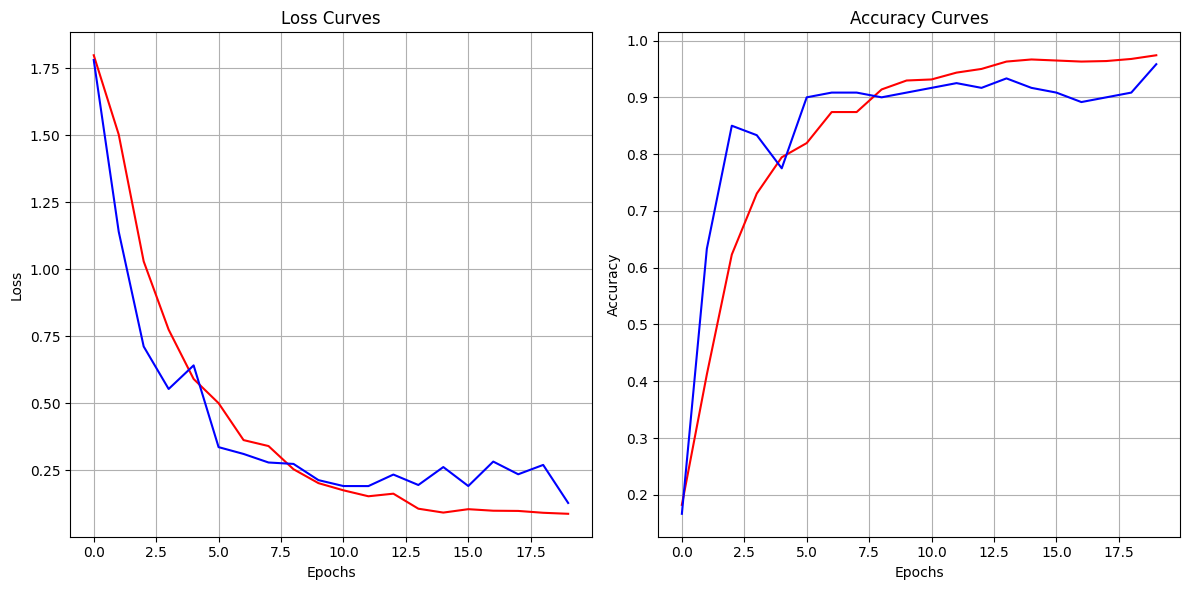

In [10]:
plot_curves(history_2)

#### Evaluating model_2

In [11]:
evaluate_model(model_2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9583 - loss: 0.1272 
Evaluation result on Test Data : Loss = 0.12717290222644806, accuracy = 0.9583333134651184


#### Model_3 with 3 Dropout layers (regularization)

In [12]:
model_3 = Sequential([
    Conv2D(
        filters=16,
        kernel_size=3,
        padding='same',
        activation='relu',
        input_shape=(64, 64, 3)
    ),
    MaxPooling2D(2),
    Dropout(0.25),

    Conv2D(
        filters=32,
        kernel_size=3,
        padding='same',
        activation='relu'
    ),
    MaxPooling2D(2),
    Dropout(0.25),

    Conv2D(
        filters=64,
        kernel_size=3,
        padding='same',
        activation='relu'
    ),
    MaxPooling2D(2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

#### Training model_3

In [13]:
model_3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_3 = model_3.fit(
    X_train,
    y_train_one_hot,
    batch_size=8,
    epochs=20,
    verbose=1,
    validation_data=(X_test, y_test_one_hot)
)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1731 - loss: 1.8161 - val_accuracy: 0.1667 - val_loss: 1.7916
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1741 - loss: 1.7942 - val_accuracy: 0.1667 - val_loss: 1.7905
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2009 - loss: 1.7800 - val_accuracy: 0.2833 - val_loss: 1.7222
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3056 - loss: 1.6673 - val_accuracy: 0.5417 - val_loss: 1.3824
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5046 - loss: 1.2941 - val_accuracy: 0.6583 - val_loss: 1.1520
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6019 - loss: 1.0470 - val_accuracy: 0.7917 - val_loss: 0.7881
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6907 - loss: 0.8403 - val_accuracy: 0.8250 - val_loss: 0.6396
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7370 - loss: 0.7165 - val_accuracy: 0.

#### Ploting curvec for model_3

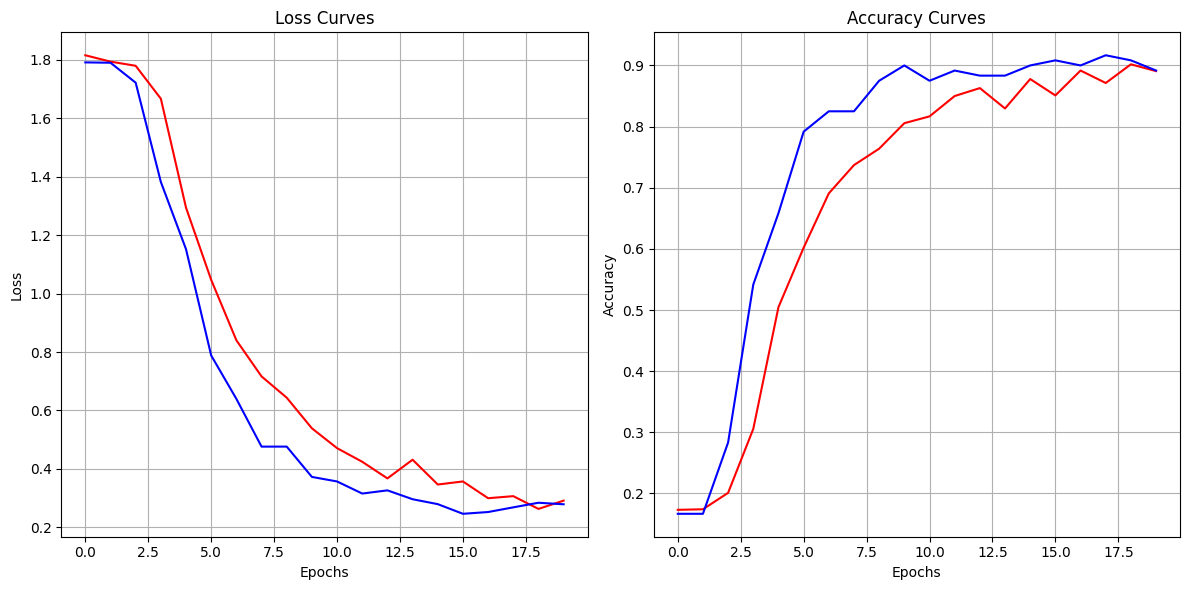

In [14]:
plot_curves(history_3)

#### Evaluating model_3

In [15]:
evaluate_model(model_3)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8917 - loss: 0.2786 
Evaluation result on Test Data : Loss = 0.2786397337913513, accuracy = 0.8916666507720947


#### Model_4 with sigmoid activation

In [16]:
model_4 = Sequential([
    Conv2D(
        filters=16,
        kernel_size=3,
        padding='same',
        activation='sigmoid', # <- this
        input_shape=(64, 64, 3)
    ),
    MaxPooling2D(2),
    Dropout(0.25),

    Conv2D(
        filters=32,
        kernel_size=3,
        padding='same',
        activation='relu'
    ),
    MaxPooling2D(2),
    Dropout(0.25),

    Conv2D(
        filters=64,
        kernel_size=3,
        padding='same',
        activation='relu'
    ),
    MaxPooling2D(2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

In [17]:
model_4.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_4 = model_4.fit(
    X_train,
    y_train_one_hot,
    batch_size=32,
    epochs=20,
    verbose=1,
    validation_data=(X_test, y_test_one_hot)
)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1657 - loss: 1.8819 - val_accuracy: 0.1667 - val_loss: 1.7917
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1750 - loss: 1.7925 - val_accuracy: 0.1500 - val_loss: 1.7918
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1519 - loss: 1.7945 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1806 - loss: 1.7917 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1593 - loss: 1.7926 - val_accuracy: 0.1667 - val_loss: 1.7917
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1815 - loss: 1.7908 - val_accuracy: 0.1667 - val_loss: 1.7914
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1870 - loss: 1.7882 - val_accuracy: 0.3417 - val_loss: 1.7863
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2120 - loss: 1.7725 - val_accuracy: 0.3750 - v

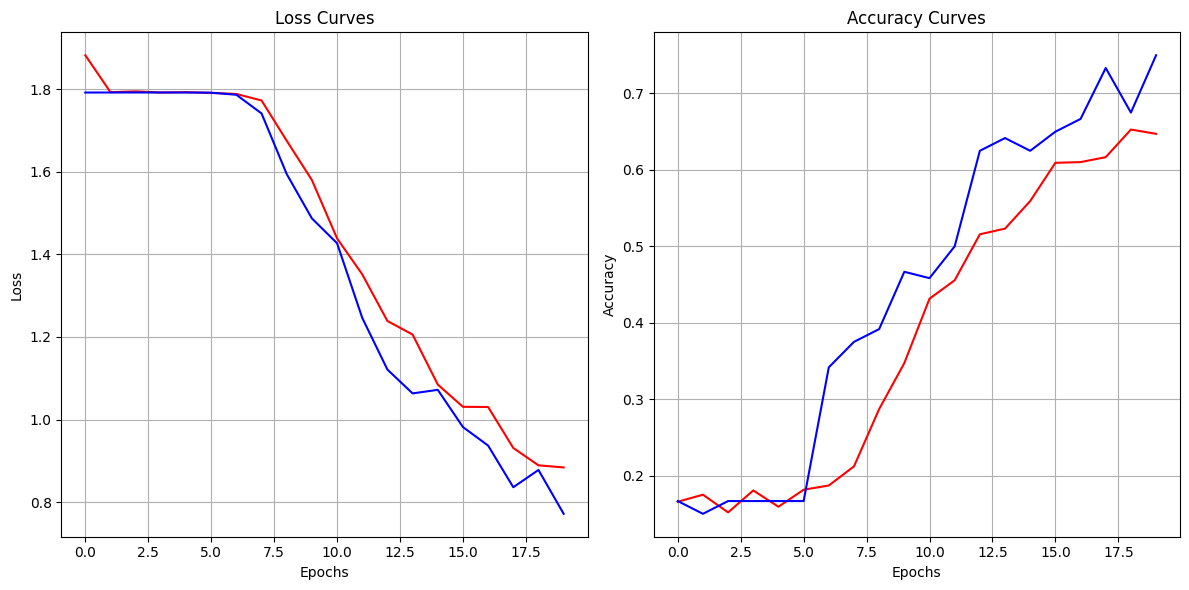

In [18]:
plot_curves(history_4)

In [19]:
evaluate_model(model_4)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7500 - loss: 0.7720
Evaluation result on Test Data : Loss = 0.772011935710907, accuracy = 0.75
